## Indlæser masterdatasættet

In [59]:
import pandas as pd
import numpy as np
import os
import statsmodels.formula.api as smf

BASE = "/Users/PC/Documents/Speciale/Analyse/Speciale"
CLEAN_DIR = os.path.join(BASE, "clean")

master = pd.read_csv(os.path.join(CLEAN_DIR, "master_monthly.csv"))
master["month"] = pd.to_datetime(master["month"])

def stjerner(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

In [49]:
master["dkk_ret"] = master["USDDKK"].pct_change()
master["usd_dkk_ret"] = master["dkk_ret"]
master["eur_ret"] = master["EURUSD"].pct_change()

master["vwretd_q"]      = np.log(1 + master["vwretd"]).rolling(3).sum()
master["sprtrn_q"]      = np.log(1 + master["sprtrn"]).rolling(3).sum()
master["bond_ret_q"]    = np.log(1 + master["bond_ret"]).rolling(3).sum()
master["usd_dkk_ret_q"] = np.log(1 + master["usd_dkk_ret"]).rolling(3).sum()

print("corr(usd_dkk_ret, eur_ret):", master["usd_dkk_ret"].corr(master["eur_ret"]).round(3))

corr(usd_dkk_ret, eur_ret): -0.999


### Dollarens afdækningsegenskab over tid

In [50]:
# Rullende korrelationer
win = 36
# Samme definitioner som i hedge ratio: USD/DKK og US-aktier
master["corr_usd_eq"] = master["usd_dkk_ret"].rolling(win).corr(master["vwretd"])

# tjek
print(master[["month","corr_usd_eq"]].dropna().head(3))
print(master[["month","corr_usd_eq"]].dropna().tail(6))

        month  corr_usd_eq
36 2018-01-31    -0.045747
37 2018-02-28    -0.113533
38 2018-03-31    -0.073983
         month  corr_usd_eq
126 2025-07-31    -0.327869
127 2025-08-31    -0.312045
128 2025-09-30    -0.248328
129 2025-10-31    -0.246874
130 2025-11-30    -0.204327
131 2025-12-31    -0.284710


In [51]:
# 1) usd_dkk_ret bør være næsten spejlbillede af eur_ret (kronen følger euroen)
#    Når dollaren styrkes: EUR/USD falder (eur_ret<0) OG usd_dkk_ret>0 -> korrelation ~ -1
print("corr(usd_dkk_ret, eur_ret):", master["usd_dkk_ret"].corr(master["eur_ret"]).round(3))

# 2) Fuld-periode korrelation bør være negativ (matcher h* < 1)
print("corr(usd_dkk_ret, vwretd):", master["usd_dkk_ret"].corr(master["vwretd"]).round(3))

corr(usd_dkk_ret, eur_ret): -0.999
corr(usd_dkk_ret, vwretd): -0.255


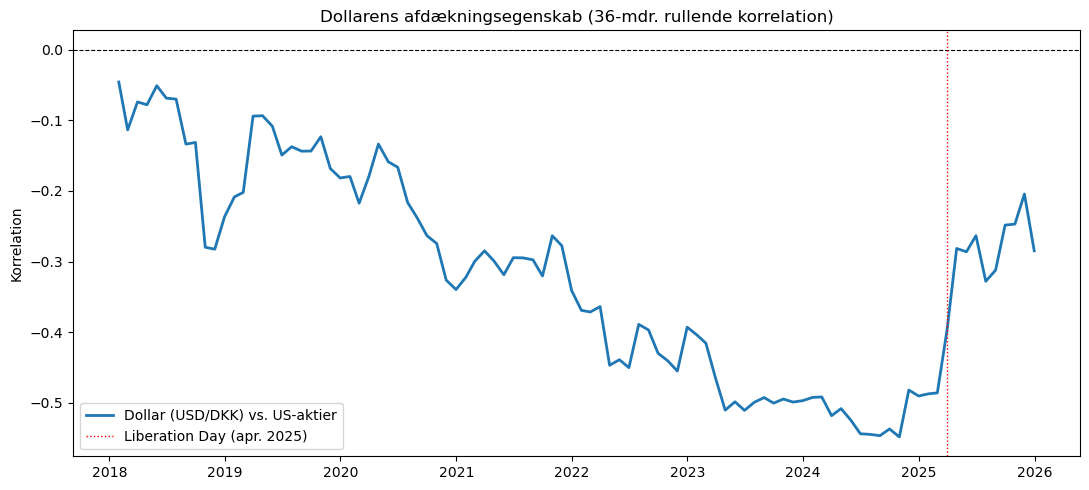

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,5))
d = master.dropna(subset=["corr_usd_eq"])
ax.plot(d["month"], d["corr_usd_eq"], label="Dollar (USD/DKK) vs. US-aktier", lw=2)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":", label="Liberation Day (apr. 2025)")
ax.set_title(f"Dollarens afdækningsegenskab ({win}-mdr. rullende korrelation)")
ax.set_ylabel("Korrelation")
ax.legend()
plt.tight_layout()
plt.show()

Plottet viser om dollarens negative samvariation med US-aktier ændrer sig over tid.

In [53]:
def hedge_ratio(asset_ret, fx_ret, data):
    d = data.dropna(subset=[asset_ret, fx_ret])
    cov = d[asset_ret].cov(d[fx_ret])
    var = d[fx_ret].var()
    return 1 + cov / var

print("=== h* på kvartalsvise, overlappende afkast ===")
for navn, col in [("US aktier (CRSP)", "vwretd_q"), ("S&P 500", "sprtrn_q"), ("US statsobl.", "bond_ret_q")]:
    h = hedge_ratio(col, "usd_dkk_ret_q", master)
    print(f"{navn}: h* = {h:.3f}")

def hedge_ratio_hac(asset_ret, fx_ret, data, maxlags=6):
    d = data.dropna(subset=[asset_ret, fx_ret]).copy()
    m = smf.ols(f"{asset_ret} ~ {fx_ret}", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    h_star = 1 + m.params[fx_ret]
    return h_star, m.bse[fx_ret], m.pvalues[fx_ret]

print("\n=== h* med HAC-standardfejl (kvartalsvis) ===")
for navn, col in [("US aktier (CRSP)", "vwretd_q"), ("S&P 500", "sprtrn_q"), ("US statsobl.", "bond_ret_q")]:
    h, se, p = hedge_ratio_hac(col, "usd_dkk_ret_q", master)
    print(f"{navn}: h* = {h:.3f}{stjerner(p)}  (SE={se:.3f}, p={p:.3f})")

=== h* på kvartalsvise, overlappende afkast ===
US aktier (CRSP): h* = 0.409
S&P 500: h* = 0.472
US statsobl.: h* = 0.699

=== h* med HAC-standardfejl (kvartalsvis) ===
US aktier (CRSP): h* = 0.409**  (SE=0.251, p=0.019)
S&P 500: h* = 0.472**  (SE=0.243, p=0.030)
US statsobl.: h* = 0.699***  (SE=0.087, p=0.001)


# TPU 

In [54]:
master["lnTPU"]   = np.log(master["TPU"])
master["lnTPU_z"] = (master["lnTPU"] - master["lnTPU"].mean()) / master["lnTPU"].std()

d = master.dropna(subset=["vwretd_q", "usd_dkk_ret_q", "lnTPU_z"]).copy()
m = smf.ols("vwretd_q ~ usd_dkk_ret_q * lnTPU_z", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(m.summary().tables[1])

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.0292      0.007      4.118      0.000       0.015       0.043
usd_dkk_ret_q            -0.6380      0.209     -3.055      0.002      -1.047      -0.229
lnTPU_z                   0.0083      0.006      1.343      0.179      -0.004       0.020
usd_dkk_ret_q:lnTPU_z     0.3827      0.136      2.806      0.005       0.115       0.650


# GPR

In [55]:
# GPR (global usikkerhedsindeks)
master["lnGPR"]   = np.log(master["GPR"])
master["lnGPR_z"] = (master["lnGPR"] - master["lnGPR"].mean()) / master["lnGPR"].std()

d = master.dropna(subset=["vwretd_q", "usd_dkk_ret_q", "lnGPR_z"]).copy()
m = smf.ols("vwretd_q ~ usd_dkk_ret_q * lnGPR_z", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(m.summary().tables[1])

                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.0266      0.007      3.581      0.000       0.012       0.041
usd_dkk_ret_q            -0.5811      0.204     -2.848      0.004      -0.981      -0.181
lnGPR_z                  -0.0120      0.009     -1.372      0.170      -0.029       0.005
usd_dkk_ret_q:lnGPR_z     0.0951      0.196      0.485      0.628      -0.290       0.480


# GPR_USA

In [56]:
# GPRC_USA (amerikansk-specifikt geopolitisk risikoindeks)
master["lnGPR_USA"]   = np.log(master["GPRC_USA"])
master["lnGPR_USA_z"] = (master["lnGPR_USA"] - master["lnGPR_USA"].mean()) / master["lnGPR_USA"].std()

d = master.dropna(subset=["vwretd_q", "usd_dkk_ret_q", "lnGPR_USA_z"]).copy()
m = smf.ols("vwretd_q ~ usd_dkk_ret_q * lnGPR_USA_z", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(m.summary().tables[1])

                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0268      0.007      3.590      0.000       0.012       0.041
usd_dkk_ret_q                -0.6001      0.207     -2.900      0.004      -1.006      -0.195
lnGPR_USA_z                  -0.0098      0.010     -1.008      0.314      -0.029       0.009
usd_dkk_ret_q:lnGPR_USA_z     0.1420      0.209      0.679      0.497      -0.268       0.552


# ROBUSTHEDSCHECK

In [57]:
# GPR - Threats (GPRT)
master["lnGPRT"]   = np.log(master["GPRT"])
master["lnGPRT_z"] = (master["lnGPRT"] - master["lnGPRT"].mean()) / master["lnGPRT"].std()

d = master.dropna(subset=["vwretd_q", "usd_dkk_ret_q", "lnGPRT_z"]).copy()
m = smf.ols("vwretd_q ~ usd_dkk_ret_q * lnGPRT_z", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(m.summary().tables[1])

                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.0271      0.007      3.915      0.000       0.014       0.041
usd_dkk_ret_q             -0.5467      0.214     -2.550      0.011      -0.967      -0.127
lnGPRT_z                  -0.0142      0.007     -2.029      0.042      -0.028      -0.000
usd_dkk_ret_q:lnGPRT_z    -0.0834      0.176     -0.473      0.636      -0.429       0.262


In [58]:
# GPR - Acts (GPRA)
master["lnGPRA"]   = np.log(master["GPRA"])
master["lnGPRA_z"] = (master["lnGPRA"] - master["lnGPRA"].mean()) / master["lnGPRA"].std()

d = master.dropna(subset=["vwretd_q", "usd_dkk_ret_q", "lnGPRA_z"]).copy()
m = smf.ols("vwretd_q ~ usd_dkk_ret_q * lnGPRA_z", data=d).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print(m.summary().tables[1])

                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.0270      0.008      3.478      0.001       0.012       0.042
usd_dkk_ret_q             -0.6139      0.200     -3.075      0.002      -1.005      -0.223
lnGPRA_z                  -0.0069      0.008     -0.833      0.405      -0.023       0.009
usd_dkk_ret_q:lnGPRA_z     0.2462      0.167      1.473      0.141      -0.082       0.574
